In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from rpasim.gyms import IFFL2VarsGym
import control as ct

In [69]:
params = {
    "alpha": 1.0,
    "beta": 1.0,
    "gamma": 1.0,
    "delta": 1.0,
}

params_ueq2 = {
    "alpha": 2.0,
    "beta": 2.0,
    "gamma": 1.0,
    "delta": 1.0,
}    


def sys_update(t, x, u, params):

    alpha, beta, gamma, delta = [params[key] for key in ['alpha', 'beta', 'gamma', 'delta']]

    x,y = x

    dx = alpha - delta * x
    dy = beta  - gamma * x * y

    return np.array([dx, dy])


def params_u(u):
    return {
        "alpha": 1.0*u,
        "beta": 1.0*u,
        "gamma": 1.0,
        "delta": 1.0,
    }

def sys_u(u):
    return ct.nlsys(
        sys_update, states=['x', 'y'],
        inputs=0, name='IFFL', params=params_u(u))




In [45]:
def xss(params):
    return params['alpha'] / params['delta']

def yss(params):
    return params['beta'] / (params['gamma'] * xss(params))

In [71]:
xss(params_u(2)), xss(params_u(0.5)), 

(2.0, 0.5)

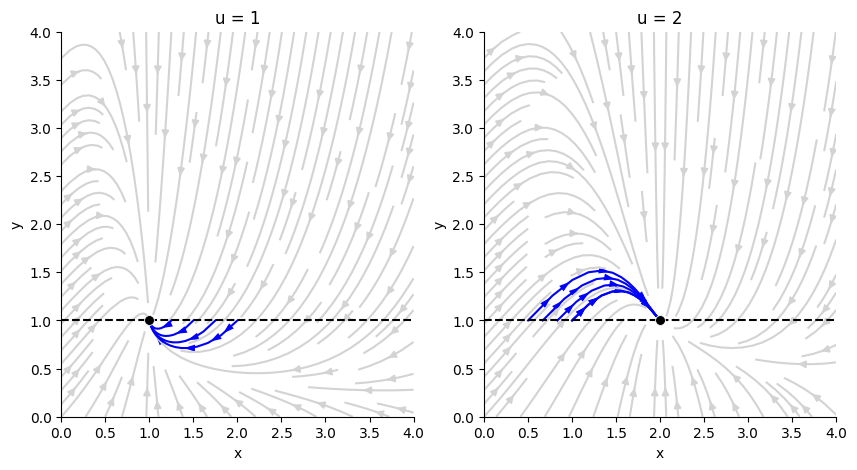

In [68]:
import control.phaseplot as pp

sys_u1 = ct.nlsys(
    sys_update, states=['x', 'y'],
    inputs=0, name='IFFL', params=params)

sys_u2 = ct.nlsys(
    sys_update, states=['x', 'y'],
    inputs=0, name='IFFL', params=params_ueq2)


fig, axs = plt.subplots(figsize=(10,5), ncols=2)


axis_limits = [0, 4, 0, 4]

ax = axs[0]
ct.phase_plane_plot(sys_u1, axis_limits, color='lightgray', ax=ax, plot_separatrices=False)
# pp.streamlines(
#     sys_u1, np.array([[2, 0]]), 2 * np.pi, arrows=6, color='b', ax=ax)
sns.scatterplot(x=[xss(params)], y=[yss(params)], color='black', ax=ax, zorder=10, s=50)
for plus_x in np.linspace(0, 1, 5):
    pp.streamlines(
        sys_u1, np.array([[xss(params) + plus_x, yss(params)]]), timedata=10, arrows=4, color='b', ax=ax)

ax.set_title('u = 1')

ax = axs[1]
ct.phase_plane_plot(sys_u2, axis_limits, color='lightgray', ax=ax, plot_separatrices=False)
pp.streamlines(
    sys_u2, np.array([[xss(params), yss(params)]]), timedata=10, arrows=4, color='b', ax=ax)
sns.scatterplot(x=[xss(params_ueq2)], y=[yss(params_ueq2)], color='black', ax=ax, zorder=10, s=50)

for minus_x in np.linspace(0, 0.5, 4):
    pp.streamlines(
        sys_u2, np.array([[xss(params) - minus_x, yss(params)]]), timedata=10, arrows=4, color='b', ax=ax)
ax.set_title('u = 2')


for ax in axs:
    sns.despine(ax=ax) # , left=True, bottom=True
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axhline(1, color='black', ls='--')

# Lower u gradually - computing the trajectory from the previous state to the next equilibrium point:

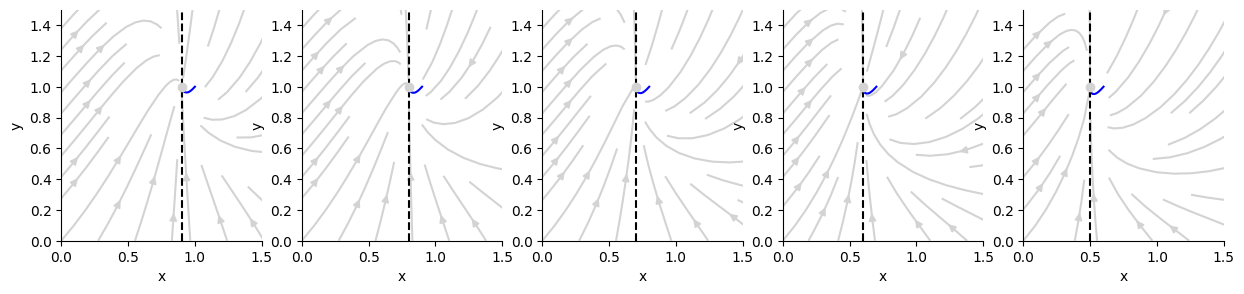

In [82]:
import control.phaseplot as pp


fig, axs = plt.subplots(figsize=(15,3), ncols=5)

us = [1, 0.9, 0.8, 0.7, 0.6, 0.5]

for i, ax in enumerate(axs):

    # start at ss for u=1, then move towards ss for u=0.5:
    xss_u = xss(params_u(us[i]))
    yss_u = yss(params_u(us[i]))

    ct.phase_plane_plot(sys_u(us[i+1]), axis_limits, color='lightgray', ax=ax, plot_separatrices=False)

    pp.streamlines(
        sys_u(us[i+1]), np.array([[xss_u, yss_u]]), timedata=10, arrows=4, color='b', ax=ax)
    
    ax.axvline(xss(params_u(us[i+1])), color='black', ls='--')

for ax in axs:
    sns.despine(ax=ax) # , left=True, bottom=True
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(0, 1.5)
    ax.set_ylim(0, 1.5)

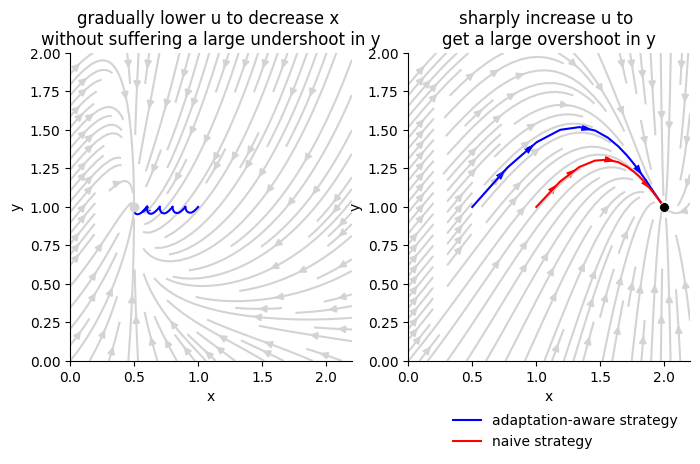

In [124]:
import control.phaseplot as pp


fig, axs = plt.subplots(figsize=(8,4), ncols=2)


# gradually lower u to lower x without suffering a large undershoot in y
ax = axs[0]

us = [1, 0.9, 0.8, 0.7, 0.6, 0.5]

axis_limits = [0, 2.2, 0, 2]
ct.phase_plane_plot(sys_u(0.5), axis_limits, color='lightgray', ax=ax, plot_separatrices=False)


for i, u in enumerate(us[:-1]):

    # start at ss for u=1, then move towards ss for u=0.5:
    xss_u = xss(params_u(us[i]))
    yss_u = yss(params_u(us[i]))

    pp.streamlines(
        sys_u(us[i+1]), np.array([[xss_u, yss_u]]), timedata=10, arrows=4, color='b', ax=ax)
    
ax.set_title('gradually lower u to decrease x \nwithout suffering a large undershoot in y')


# sharply increase u to get a large overshoot in y:
ax = axs[1]
ct.phase_plane_plot(sys_u2, axis_limits, color='lightgray', ax=ax, plot_separatrices=False)
lines1 = pp.streamlines(
    sys_u2, np.array([[xss(params_u(0.5)), yss(params_u(0.5))]]), timedata=10, arrows=4, color='b', ax=ax)
lines1[0].set_label('adaptation-aware strategy')

lines2 = pp.streamlines(
    sys_u2, np.array([[xss(params_u(1)), yss(params_u(1))]]), timedata=10, arrows=4, color='red', ax=ax)
lines2[0].set_label('naive strategy')


sns.scatterplot(x=[xss(params_ueq2)], y=[yss(params_ueq2)], color='black', ax=ax, zorder=10, s=50)
ax.set_title('sharply increase u to \nget a large overshoot in y')


axs[1].legend(frameon=False, bbox_to_anchor=(1.0, -0.13))


for ax in axs:
    sns.despine(ax=ax) # , left=True, bottom=True
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    # ax.set_xlim(0, 2.5)
    # ax.set_ylim(0, 2.5)

# fig.tight_layout()

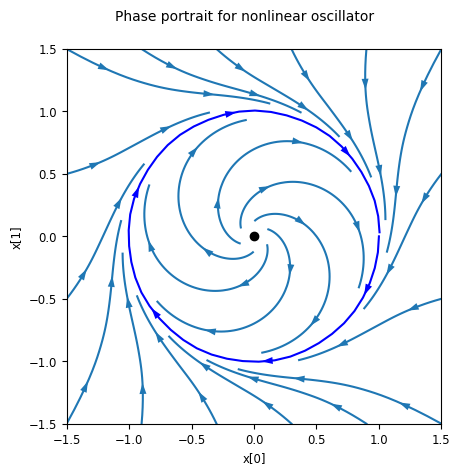

In [ ]:


def oscillator_update(t, x, u, params):
    return [x[1] + x[0] * (1 - x[0]**2 - x[1]**2),
            -x[0] + x[1] * (1 - x[0]**2 - x[1]**2)]
oscillator = ct.nlsys(
    oscillator_update, states=2, inputs=0, name='nonlinear oscillator')

ct.phase_plane_plot(oscillator, [-1.5, 1.5, -1.5, 1.5], 0.9,
    plot_streamlines=True)
pp.streamlines(
    oscillator, np.array([[0, 0]]), 1.5,
    gridtype='circlegrid', gridspec=[0.5, 6], dir='both')

pp.streamlines(
    oscillator, np.array([[1, 0]]), 2 * np.pi, arrows=6, color='b')


plt.gca().set_aspect('equal')

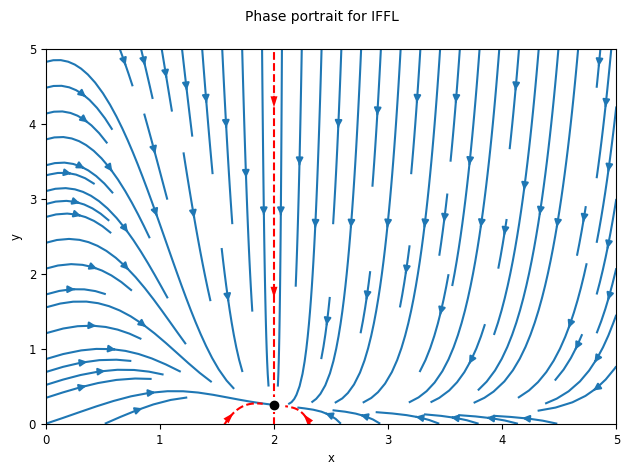

In [20]:
sys = ct.nlsys(
    sys_update, states=['x', 'y'],
    inputs=0, name='IFFL', params=params_ueq2)


axis_limits = [0, 5, 0, 5]
ct.phase_plane_plot(sys, axis_limits)


# Scratch:

In [ ]:
CONTROLLED_PARAMS = ["alpha", "delta", "beta", "gamma"]
BASE_PARAMS = {"alpha": 1.0, "delta": 1.0, "beta": 1.0, "gamma": 1.0}


def steady_state(control):
    """Compute (x_ss, y_ss) for given control multipliers [u_alpha, u_delta, u_beta, u_gamma].

    Effective params: alpha_eff = base_alpha * u_alpha, etc.
    x_ss = alpha_eff / delta_eff
    y_ss = beta_eff * delta_eff / (alpha_eff * gamma_eff)
    """
    alpha_eff = BASE_PARAMS["alpha"] * control[0]
    delta_eff = BASE_PARAMS["delta"] * control[1]
    beta_eff = BASE_PARAMS["beta"] * control[2]
    gamma_eff = BASE_PARAMS["gamma"] * control[3]
    x_ss = alpha_eff / delta_eff
    y_ss = beta_eff * delta_eff / (alpha_eff * gamma_eff)
    return x_ss, y_ss


def make_env(initial_state, time_horizon=10.0):
    return IFFL2VarsGym(
        reward_fn=lambda state, time: state[1] ** 2,
        initial_state=torch.tensor(initial_state, dtype=torch.float32),
        time_horizon=time_horizon,
        base_params=dict(BASE_PARAMS),
        dt=0.1,
        n_reward_steps=3000,
        controlled_params=CONTROLLED_PARAMS,
        action_low=0.5,
        action_high=2.0,
        ode_method="rk4",
    )


def run_simulation(env, action_schedule):
    """Run a simulation with a list of (n_steps, action) tuples.

    action_schedule: list of (n_steps, action_array_or_callable)
        If callable, called with step index within that phase.
    """
    obs, _ = env.reset()
    observations = [obs.copy()]
    actions_log = []
    times = [0.0]

    for n_steps, action_fn in action_schedule:
        for step_i in range(n_steps):
            if callable(action_fn):
                action = action_fn(step_i, n_steps)
            else:
                action = action_fn
            obs, reward, terminated, truncated, info = env.step(action)
            observations.append(obs.copy())
            actions_log.append(action.copy())
            times.append(env.current_time)
            if terminated or truncated:
                break

    return np.array(observations), np.array(actions_log), np.array(times)


def plot_simulation(observations, actions, times, title):
    fig, axes = plt.subplots(6, 1, figsize=(6, 8), sharex=True)
    fig.suptitle(title, fontsize=10, y=1.0)

    axes[0].plot(times, observations[:, 0])
    axes[0].set_ylabel("x")
    sns.despine(ax=axes[0])

    axes[1].plot(times, observations[:, 1])
    axes[1].set_ylabel("y")
    sns.despine(ax=axes[1])

    t_actions = times[1:len(actions) + 1]
    for i, name in enumerate(CONTROLLED_PARAMS):
        ax = axes[2 + i]
        ax.step(t_actions, actions[:, i], where="post")
        ax.set_ylabel(f"u_{name}")
        ax.set_ylim(0, 2.5)
        sns.despine(ax=ax)

    axes[-1].set_xlabel("time")
    fig.tight_layout()
    return fig

## Simulation 1: Step change in input (u=2 via alpha, beta)

Start at nominal steady state (all controls = 1), then apply u=2 by doubling alpha and beta for 10s.

In [ ]:
nominal = np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float32)
# u=2 via doubling alpha and beta, delta and gamma stay at 1
u2 = np.array([2.0, 1.0, 2.0, 1.0], dtype=np.float32)

x_ss, y_ss = steady_state(nominal)
print(f"Initial steady state (nominal controls): x_ss={x_ss:.3f}, y_ss={y_ss:.3f}")

env = make_env(initial_state=[x_ss, y_ss])
obs, acts, times = run_simulation(env, [
    (100, u2),  # 10s at dt=0.1
])
env.close()

plot_simulation(obs, acts, times, "Simulation 1: step change u=2 (alpha, beta doubled)");

Initial steady state (nominal controls): x_ss=1.000, y_ss=1.000


## Simulation 2: Opposite extremes

Phase 1 (0-5s): min beta/delta (0.5), max alpha/gamma (2)  
Phase 2 (5-10s): max beta/delta (2), min alpha/gamma (0.5)

In [ ]:
# action order: [alpha, delta, beta, gamma]
phase1 = np.array([2.0, 0.5, 0.5, 2.0], dtype=np.float32)
phase2 = np.array([0.5, 2.0, 2.0, 0.5], dtype=np.float32)

x_ss, y_ss = steady_state(phase1)
print(f"Initial steady state (phase1 controls): x_ss={x_ss:.3f}, y_ss={y_ss:.3f}")

env = make_env(initial_state=[x_ss, y_ss])
obs, acts, times = run_simulation(env, [
    (50, phase1),  # 5s at dt=0.1
    (50, phase2),  # 5s at dt=0.1
])
env.close()

plot_simulation(obs, acts, times, "Simulation 2: opposite extremes");

Initial steady state (phase1 controls): x_ss=4.000, y_ss=0.062


## Simulation 3: Nominal then switch

Phase 1 (0-5s): all parameters = 1  
Phase 2 (5-10s): max beta/delta (2), min alpha/gamma (0.5)

In [ ]:
nominal = np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float32)
phase2 = np.array([0.5, 2.0, 2.0, 0.5], dtype=np.float32)

x_ss, y_ss = steady_state(nominal)
print(f"Initial steady state (nominal controls): x_ss={x_ss:.3f}, y_ss={y_ss:.3f}")

env = make_env(initial_state=[x_ss, y_ss])
obs, acts, times = run_simulation(env, [
    (50, nominal),
    (50, phase2),
])
env.close()

plot_simulation(obs, acts, times, "Simulation 3: nominal then switch");

## Simulation 4: Gradual ramp then switch

Phase 1 (0-5s): gradually decrease beta/delta from 1 to 0.5, increase alpha/gamma from 1 to 2  
Phase 2 (5-10s): max beta/delta (2), min alpha/gamma (0.5)

In [ ]:
def ramp_action(step_i, n_steps):
    """Linearly interpolate from nominal to target over n_steps."""
    t = step_i / (n_steps - 1)  # 0 to 1
    alpha = 1.0 + t * (2.0 - 1.0)   # 1 -> 2
    delta = 1.0 + t * (0.5 - 1.0)   # 1 -> 0.5
    beta = 1.0 + t * (0.5 - 1.0)    # 1 -> 0.5
    gamma = 1.0 + t * (2.0 - 1.0)   # 1 -> 2
    return np.array([alpha, delta, beta, gamma], dtype=np.float32)


# Ramp starts from nominal controls
nominal = np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float32)
phase2 = np.array([0.5, 2.0, 2.0, 0.5], dtype=np.float32)

x_ss, y_ss = steady_state(nominal)
print(f"Initial steady state (nominal controls): x_ss={x_ss:.3f}, y_ss={y_ss:.3f}")

env = make_env(initial_state=[x_ss, y_ss])
obs, acts, times = run_simulation(env, [
    (50, ramp_action),
    (50, phase2),
])
env.close()

plot_simulation(obs, acts, times, "Simulation 4: gradual ramp then switch");

## Simulation 5: Sensitivity to each parameter under u=1→2 step

For each parameter (alpha, delta, beta, gamma), sweep its value from 0.5 to 2 while keeping the others at 1. Apply a step change u=2 (alpha, beta doubled) and overlay all x(t), y(t) trajectories.

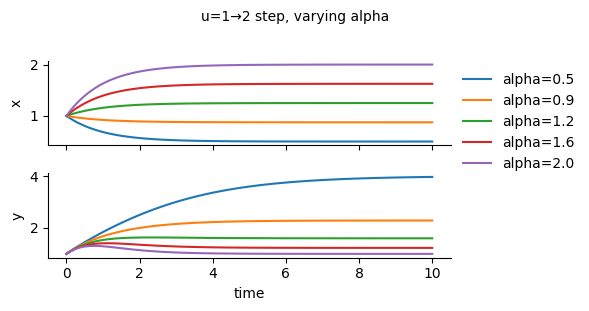

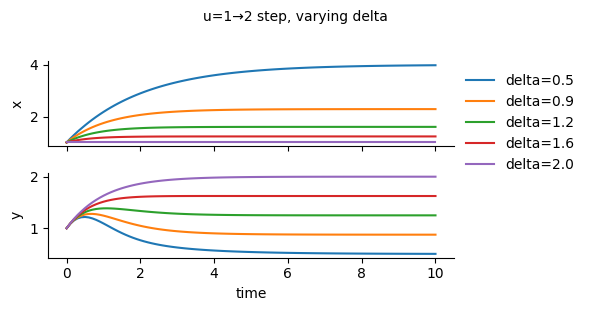

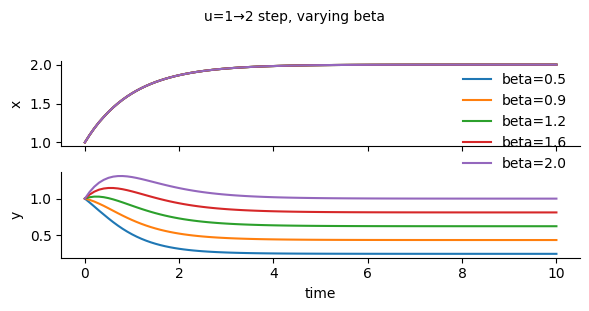

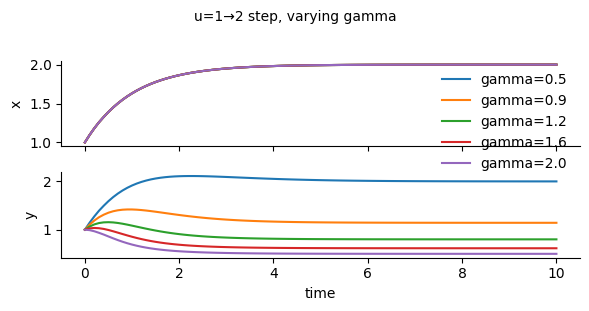

In [46]:
param_values = np.linspace(0.5, 2.0, 5)
nominal = np.ones(4, dtype=np.float32)
x_ss, y_ss = steady_state(nominal)

for param_idx, param_name in enumerate(CONTROLLED_PARAMS):
    fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(6, 3), sharex=True)
    fig.suptitle(f"u=1→2 step, varying {param_name}", fontsize=10, y=1.02)

    for val in param_values:
        # u=2 phase: double alpha and beta, set the swept param to val
        u2 = np.ones(4, dtype=np.float32)
        u2[0] = 2.0  # alpha x2
        u2[2] = 2.0  # beta x2
        u2[param_idx] = val
        # Clip to action bounds
        u2 = np.clip(u2, 0.5, 2.0)

        env = make_env(initial_state=[x_ss, y_ss])
        obs, acts, times = run_simulation(env, [(100, u2)])
        env.close()

        label = f"{param_name}={val:.1f}"
        ax_x.plot(times, obs[:, 0], label=label)
        ax_y.plot(times, obs[:, 1], label=label)

    ax_x.set_ylabel("x")
    ax_x.legend(frameon=False, bbox_to_anchor=(1, 1))
    sns.despine(ax=ax_x)

    ax_y.set_ylabel("y")
    ax_y.set_xlabel("time")
    sns.despine(ax=ax_y)

    fig.tight_layout()